C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_25956\3883423005.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=final_df, x='주용도코드명', y='사용량_KWh', palette='magma')


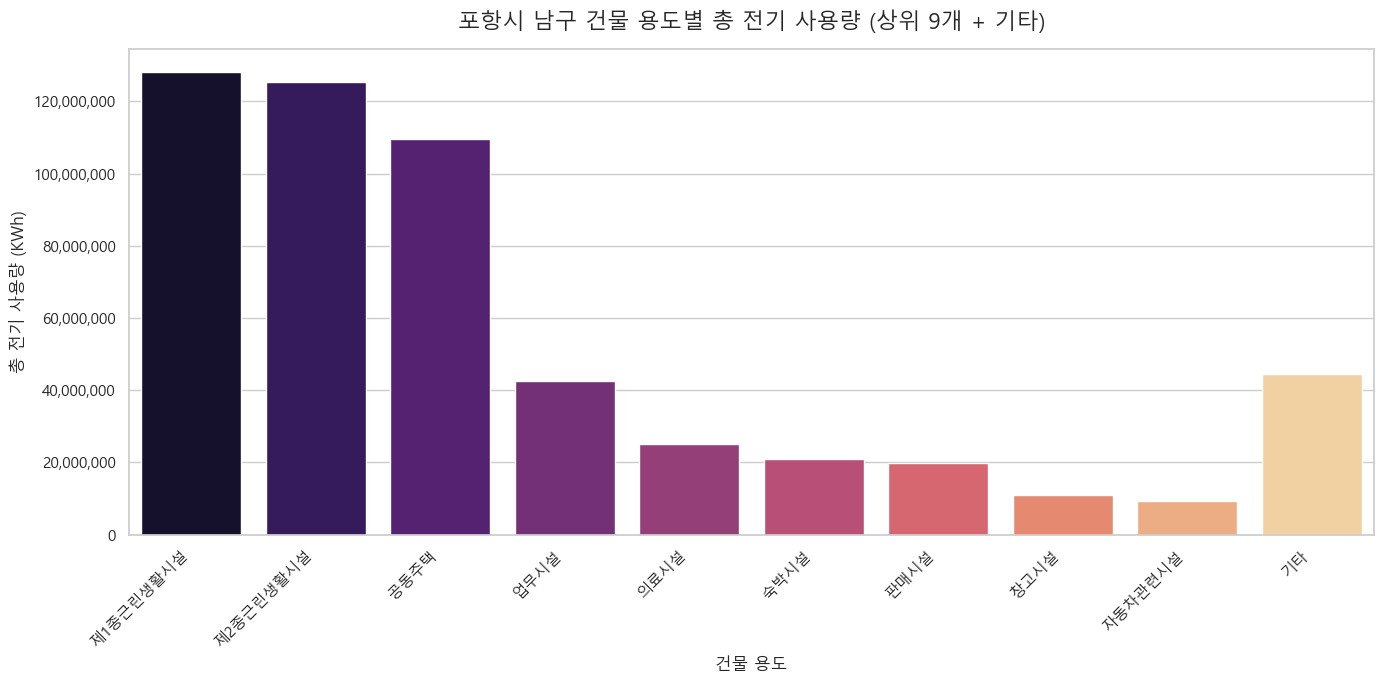

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 폰트 및 시각화 설정 (윈도우 환경 기준 맑은 고딕)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기
try:
    df = pd.read_csv('2025전기결과표.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('2025전기결과표.csv', encoding='cp949')

# 3. 용도별 총 사용량 합계 계산 (groupby sum)
grouped = df.groupby('주용도코드명')['사용량_KWh'].sum().reset_index()

# 4. 정렬 (사용량 높은 순)
grouped = grouped.sort_values(by='사용량_KWh', ascending=False)

# 5. 상위 9개 및 기타 분류
if len(grouped) > 9:
    top9 = grouped.iloc[:9].copy()
    
    # 10위부터 나머지 전체 건물의 총 사용량을 합산
    others_kwh = grouped.iloc[9:]['사용량_KWh'].sum()
    
    others_df = pd.DataFrame({
        '주용도코드명': ['기타'],
        '사용량_KWh': [others_kwh]
    })
    
    final_df = pd.concat([top9, others_df], ignore_index=True)
else:
    final_df = grouped

# 6. 시각화 (Barplot)
plt.figure(figsize=(14, 7))

# 막대그래프 그리기 (색상은 magma로 변경하여 시각적 깊이를 주었습니다)
ax = sns.barplot(data=final_df, x='주용도코드명', y='사용량_KWh', palette='magma')

plt.title('포항시 남구 건물 용도별 총 전기 사용량 (상위 9개 + 기타)', fontsize=16, pad=15)
plt.xlabel('건물 용도', fontsize=12)
plt.ylabel('총 전기 사용량 (KWh)', fontsize=12)

# y축의 숫자를 보기 쉽게 콤마(,) 형식으로 변경 (과학적 표기법 방지)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()

# 화면에 출력
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_25956\2040751014.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x='주용도코드명', y='총사용량', palette='magma', ax=axes[0])
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_25956\2040751014.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x='주용도코드명', y='평균사용량', palette='viridis', ax=axes[1])


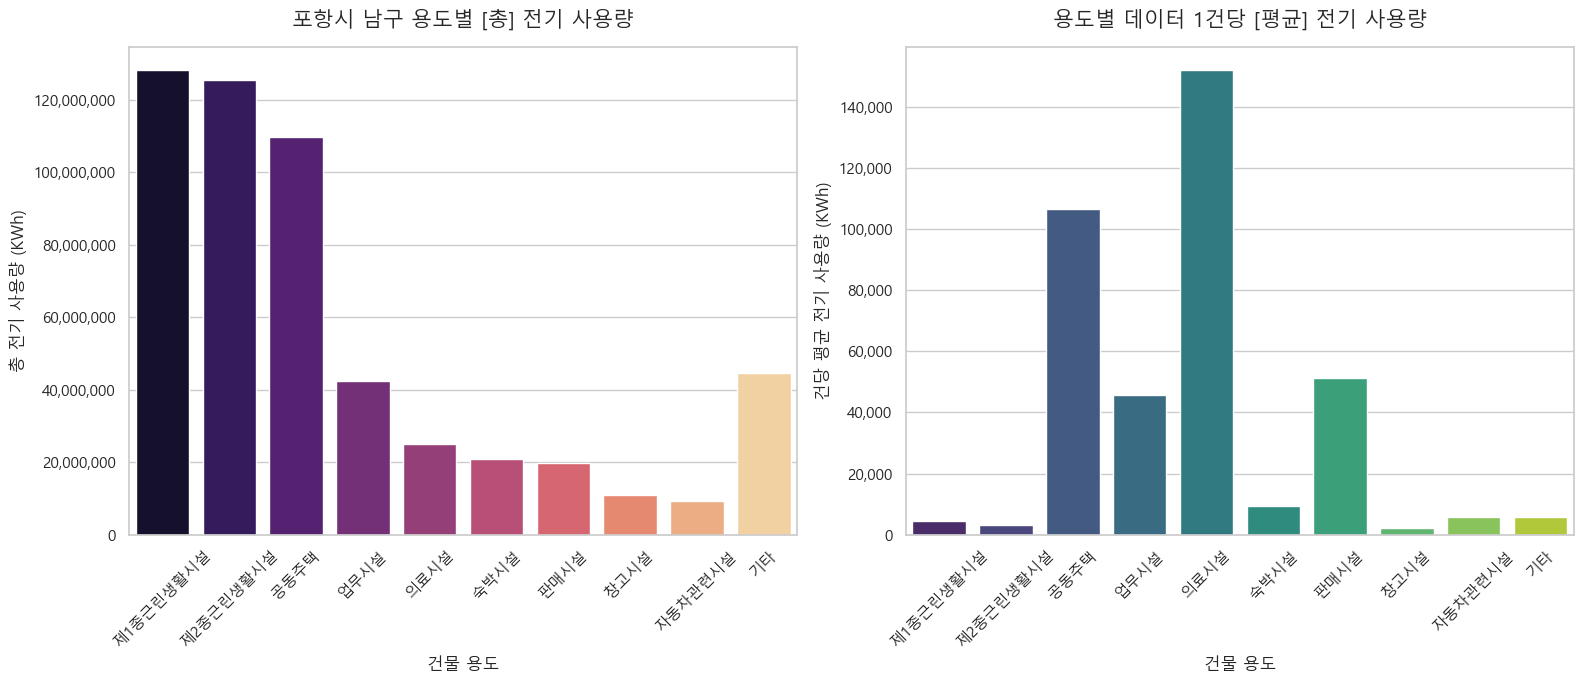

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 폰트 및 시각화 설정 (윈도우 환경 기준 맑은 고딕)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 2. 데이터 불러오기
try:
    df = pd.read_csv('2025전기결과표.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('2025전기결과표.csv', encoding='cp949')

# 3. 용도별 총사용량 및 데이터 개수 계산 (데이터 길이로 나누기 위함)
grouped = df.groupby('주용도코드명').agg(
    총사용량=('사용량_KWh', 'sum'),
    데이터수=('사용량_KWh', 'count') # 데이터의 행 길이
).reset_index()

# 4. 정렬 (총 사용량 높은 순)
grouped = grouped.sort_values(by='총사용량', ascending=False)

# 5. 상위 9개 및 '기타' 분류
if len(grouped) > 9:
    top9 = grouped.iloc[:9].copy()
    top9['평균사용량'] = top9['총사용량'] / top9['데이터수']
    
    # 10위부터 나머지의 합계 및 평균 계산
    others_total = grouped.iloc[9:]['총사용량'].sum()
    others_count = grouped.iloc[9:]['데이터수'].sum()
    others_avg = others_total / others_count if others_count > 0 else 0
    
    others_df = pd.DataFrame({
        '주용도코드명': ['기타'],
        '총사용량': [others_total],
        '데이터수': [others_count],
        '평균사용량': [others_avg]
    })
    
    # 데이터 병합
    final_df = pd.concat([top9, others_df], ignore_index=True)
else:
    grouped['평균사용량'] = grouped['총사용량'] / grouped['데이터수']
    final_df = grouped

# ================= 시각화 시작 =================
# 1행 2열의 도화지 생성
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# [그래프 1] 총 전기 사용량 (왼쪽)
sns.barplot(data=final_df, x='주용도코드명', y='총사용량', palette='magma', ax=axes[0])
axes[0].set_title('포항시 남구 용도별 [총] 전기 사용량', fontsize=15, pad=15)
axes[0].set_xlabel('건물 용도', fontsize=12)
axes[0].set_ylabel('총 전기 사용량 (KWh)', fontsize=12)
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].tick_params(axis='x', rotation=45)

# [그래프 2] 데이터 1건당 평균 전기 사용량 (오른쪽)
sns.barplot(data=final_df, x='주용도코드명', y='평균사용량', palette='viridis', ax=axes[1])
axes[1].set_title('용도별 데이터 1건당 [평균] 전기 사용량', fontsize=15, pad=15)
axes[1].set_xlabel('건물 용도', fontsize=12)
axes[1].set_ylabel('건당 평균 전기 사용량 (KWh)', fontsize=12)
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout() # 그래프 간격 자동 조절
plt.show()